In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

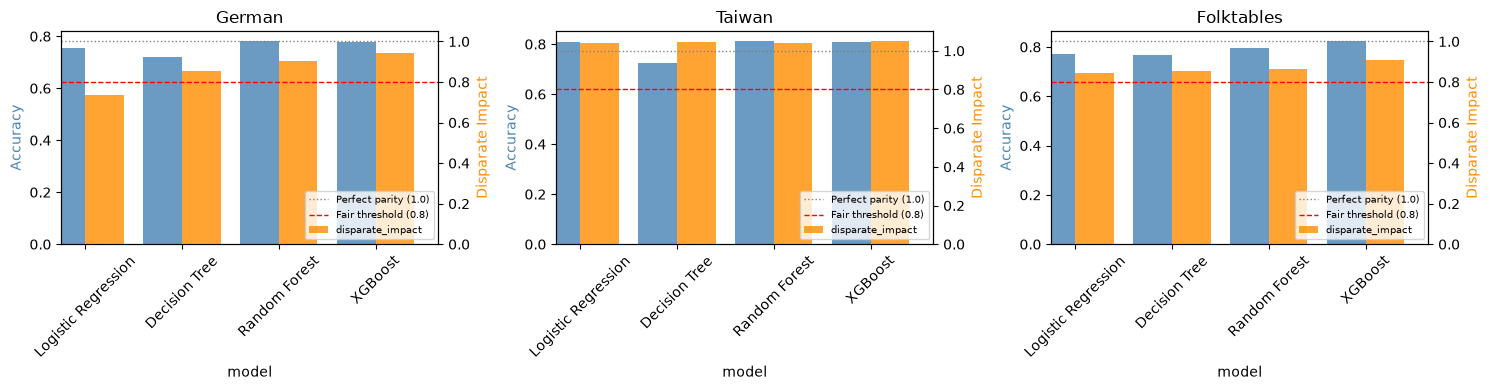

In [5]:
datasets = ['german', 'taiwan', 'folktables']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ds in zip(axes, datasets):
    df = pd.read_csv(f'../results/baseline_{ds}.csv', index_col=0)
    ax2 = ax.twinx()
    df['accuracy'].plot(kind='bar', ax=ax, color='steelblue', width=0.4, position=1, alpha=0.8)
    df['disparate_impact'].plot(kind='bar', ax=ax2, color='darkorange', width=0.4, position=0, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax2.axhline(1.0, color='gray', linestyle=':', linewidth=1, label='Perfect parity (1.0)')
    ax2.axhline(0.8, color='red', linestyle='--', linewidth=1, label='Fair threshold (0.8)')
    ax2.legend(fontsize=7, loc='lower right')
    ax.set_title(ds.capitalize())
    ax.set_ylabel('Accuracy', color='steelblue')
    ax2.set_ylabel('Disparate Impact', color='darkorange')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/accuracy_vs_fairness.png')
plt.show()

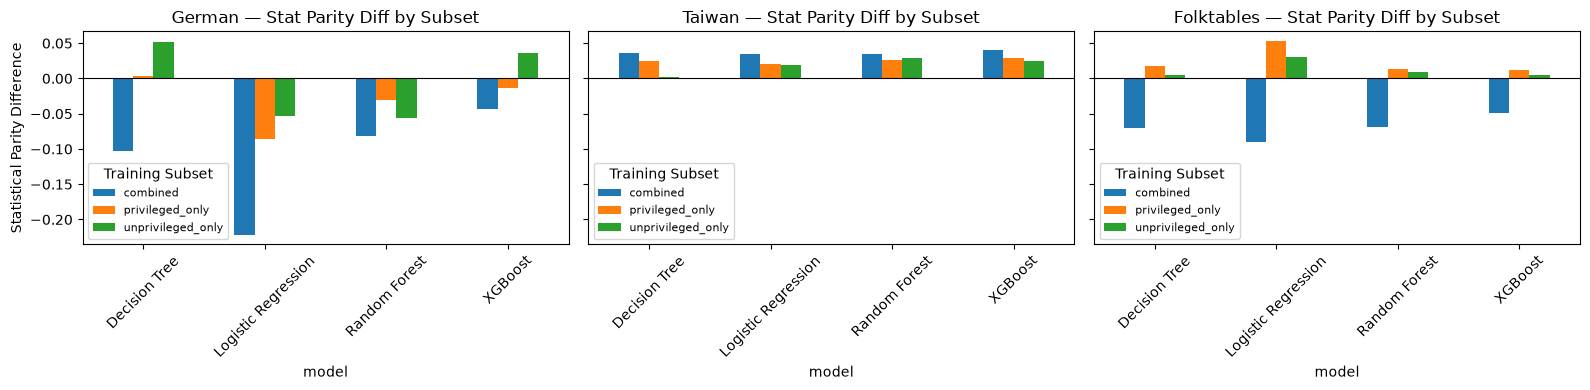

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, ds in zip(axes, datasets):
    df = pd.read_csv(f'../results/subset_{ds}.csv', index_col=[0, 1])
    pivot = df['stat_parity_diff'].unstack(level=0)
    pivot.plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{ds.capitalize()} — Stat Parity Diff by Subset')
    ax.set_ylabel('Statistical Parity Difference')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Training Subset', fontsize=8)

plt.tight_layout()
plt.savefig('../results/subset_comparison.png')
plt.show()

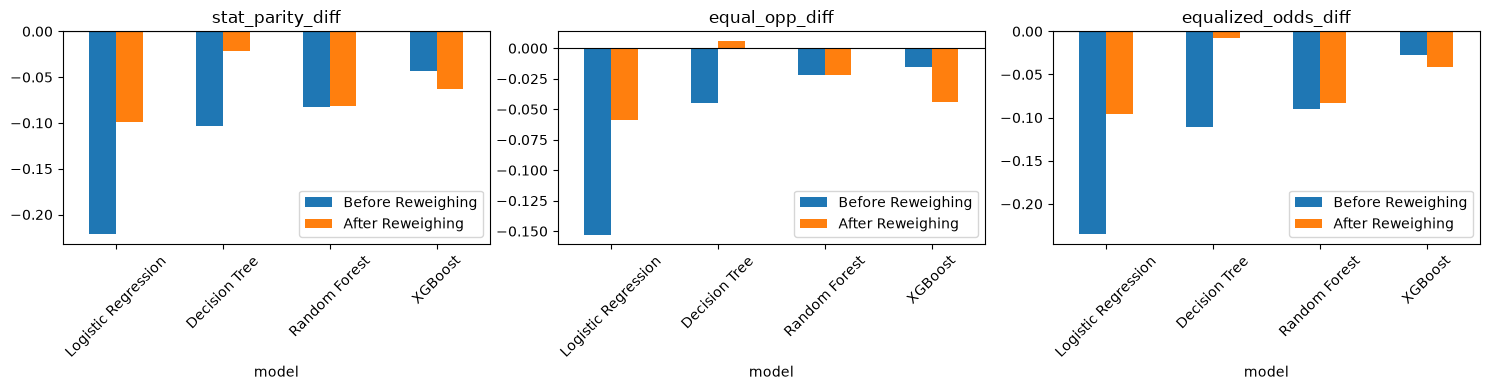

In [7]:
before = pd.read_csv('../results/baseline_german_for_comparison.csv', index_col=0)
after = pd.read_csv('../results/reweighing_german.csv', index_col=0)

metrics_to_plot = ['stat_parity_diff', 'equal_opp_diff', 'equalized_odds_diff']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, metrics_to_plot):
    comparison = pd.DataFrame({'Before Reweighing': before[metric], 'After Reweighing': after[metric]})
    comparison.plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/reweighing_comparison.png')
plt.show()